## Import 

In [59]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

## Data Load & Check Data

In [60]:
train = pd.read_csv('open/train.csv')
test = pd.read_csv('open/test.csv')

train.head()

,ID,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,class3,class4,re_registration,contest_award,nationality,inflow_route,whyBDA,what_to_gain,hope_for_group,previous_class_3,previous_class_4,previous_class_5,previous_class_6,previous_class_7,previous_class_8,major_field,desired_career_path,completed_semester,project_type,time_input,desired_job,certificate_acquisition,desired_certificate,desired_job_except_data,incumbents_level,incumbents_lecture,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participation,idea_contest,onedayclass_topic,completed
0,TRAIN_000,9,22,"복수 전공 ( 다중전공, 이중전공 포함 )",경제통상학,자연과학,False,대학생,1,4.0,NaN,NaN,아니요,NaN,내국인,에브리타임,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",프로젝트 경험,네. 온라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,"자연과학, 사회과학",대학원 진학,4.0,팀,2.0,C. 데이터 사이언티스트,컴퓨터활용능력,"ADsP, SQLD, 빅데이터 분석 기사, 태블로 관련 자격증, 구글 애널리스트",A. 금융 / 보험 직무,시니어 (10년차 ~),산업 트렌드 (예시: ChatGPT로 인한 직무 변화),해외 기업 (빅테크),"온, 오프라인 동시",100명 이상의 리스너와 10명 이상의 현직자,다양한 사람들과 만나서 생각을 교류할 수 있기 때문,"구글 딥마인드, 카카오 브레인","M. 전문, 과학 및 기술 서비스업",NaN,NaN,"Python 응용, 데이터 시각화 (Matplotlib, Seaborn 등), 머신...",0
1,TRAIN_001,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",자연과학,IT(컴퓨터 공학 포함),True,대학생,8,NaN,NaN,NaN,아니요,NaN,내국인,지인 추천,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",데이터 분석 역량,네. 오프라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,사회과학,취업,6.0,팀,3.0,"B. 데이터 분석가, C. 데이터 사이언티스트",없음,"ADsP, SQLD, 빅데이터 분석 기사, 정보처리기사","D. 소프트웨어 개발자, F. PM / 서비스 기획자",주니어 (0~3년차),커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정),국내 빅테크 IT 계열 (네카라쿠배당토),오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,더 많은 사람들이 있으면 제가 예상하지 못한 질문도 할 수 있다고 생각하기 때문입니다.,제일 기획,"J. 정보통신업, O. 공공 행정, 국방 및 사회보장 행정",NaN,NaN,머신러닝 / 딥러닝 응용,0
2,TRAIN_002,9,27,단일 전공,예체능,NaN,False,대학생,7,NaN,NaN,NaN,아니요,NaN,내국인,인스타그램,"BDA 학회원만의 혜택을 누리고 싶어서(현직자 강연, 잡 페스티벌, 기업연계 공모전 등)",공모전 경험,네. 오프라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,예체능,대학원 진학,8.0,개인,10.0,"B. 데이터 분석가, C. 데이터 사이언티스트, I. 마케터",ADsP,"SQLD, 빅데이터 분석 기사, 정보처리기사","A. 금융 / 보험 직무, B. 기획 / 전략 / 경영 직무, H. 마케터 / 영업관리",주니어 (0~3년차),직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁),"국내 대기업 IT 계열 (금융, 제조 ...)",오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,인원이 너무 적으면 서로 부담스러울 수 있을 것 같지만 너무 많으면 너무 피상적인 ...,Lg전자,"C. 제조업, K. 금융 및 보험업, R. 예술, 스포츠 및 여가관련 서비스업",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0
3,TRAIN_003,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",사회과학,IT(컴퓨터 공학 포함),False,대학생,7,NaN,NaN,NaN,아니요,NaN,내국인,에브리타임,혼자 공부하기 어려워서,프로젝트 경험,네. 온라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,법학,취업,8.0,팀,2.0,"B. 데이터 분석가, C. 데이터 사이언티스트","SQLD, 정보처리기사","ADsP, 빅데이터 분석 기사",A. 금융 / 보험 직무,주니어 (0~3년차),커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정),국내 빅테크 IT 계열 (네카라쿠배당토),"온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,너무 많은 인원이 강의하면 루즈해질 것 같아서,네이버,"J. 정보통신업, K. 금융 및 보험업",NaN,NaN,머신러닝 / 딥러닝 응용,1
4,TRAIN_004,9,16,"복수 전공 ( 다중전공, 이중전공 포함 )",IT(컴퓨터 공학 포함),IT(컴퓨터 공학 포함),True,대학생,8,NaN,NaN,NaN,아니요,NaN,내국인,지인 추천,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",공모전 경험,네. 오프라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,"IT (컴퓨터 공학 포함), 인문학",취업,7.0,팀,2.0,B. 데이터 분석가,ADsP,"SQLD, 정보처리기사, 태블로 관련 자격증, 구글 애널리스트","A. 금융 / 보험 직무, B. 기획 / 전략 / 경영 직무, F. PM / 서비스...",주니어 (0~3년차),직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁),"국내 대기업 IT 계열 (금융, 제조 ...)","온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,다양한 사람들에게 기회가 있으면 좋겠습니다.,네이버,"K. 금융 및 보험업, M. 전문, 과학 및 기술 서비스업, R. 예술, 스포츠 및...",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0


In [61]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               748 non-null    str    
 1   generation                       748 non-null    int64  
 2   school1                          748 non-null    int64  
 3   major type                       726 non-null    str    
 4   major1_1                         728 non-null    str    
 5   major1_2                         309 non-null    str    
 6   major_data                       748 non-null    bool   
 7   job                              748 non-null    str    
 8   class1                           748 non-null    int64  
 9   class2                           169 non-null    float64
 10  class3                           14 non-null     float64
 11  class4                           1 non-null      float64
 12  re_registration                  

## Pre-Processing

In [62]:
missing_ratio = train.isnull().mean()
columns_to_drop = missing_ratio[missing_ratio > 0.8].index.tolist()

train = train.drop(columns=columns_to_drop)
test = test.drop(columns=columns_to_drop)

train.head(2)

,ID,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,re_registration,nationality,inflow_route,whyBDA,what_to_gain,hope_for_group,major_field,desired_career_path,completed_semester,project_type,time_input,desired_job,certificate_acquisition,desired_certificate,desired_job_except_data,incumbents_level,incumbents_lecture,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,onedayclass_topic,completed
0,TRAIN_000,9,22,"복수 전공 ( 다중전공, 이중전공 포함 )",경제통상학,자연과학,False,대학생,1,4.0,아니요,내국인,에브리타임,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",프로젝트 경험,네. 온라인으로 참여하고 싶어요,"자연과학, 사회과학",대학원 진학,4.0,팀,2.0,C. 데이터 사이언티스트,컴퓨터활용능력,"ADsP, SQLD, 빅데이터 분석 기사, 태블로 관련 자격증, 구글 애널리스트",A. 금융 / 보험 직무,시니어 (10년차 ~),산업 트렌드 (예시: ChatGPT로 인한 직무 변화),해외 기업 (빅테크),"온, 오프라인 동시",100명 이상의 리스너와 10명 이상의 현직자,다양한 사람들과 만나서 생각을 교류할 수 있기 때문,"구글 딥마인드, 카카오 브레인","M. 전문, 과학 및 기술 서비스업","Python 응용, 데이터 시각화 (Matplotlib, Seaborn 등), 머신...",0
1,TRAIN_001,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",자연과학,IT(컴퓨터 공학 포함),True,대학생,8,NaN,아니요,내국인,지인 추천,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",데이터 분석 역량,네. 오프라인으로 참여하고 싶어요,사회과학,취업,6.0,팀,3.0,"B. 데이터 분석가, C. 데이터 사이언티스트",없음,"ADsP, SQLD, 빅데이터 분석 기사, 정보처리기사","D. 소프트웨어 개발자, F. PM / 서비스 기획자",주니어 (0~3년차),커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정),국내 빅테크 IT 계열 (네카라쿠배당토),오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,더 많은 사람들이 있으면 제가 예상하지 못한 질문도 할 수 있다고 생각하기 때문입니다.,제일 기획,"J. 정보통신업, O. 공공 행정, 국방 및 사회보장 행정",머신러닝 / 딥러닝 응용,0


In [63]:
missing_cols = train.columns[train.isnull().any()].tolist()

for col in missing_cols:
    mode_value = train[col].mode()[0]
    train[col] = train[col].fillna(mode_value)
    test[col] = test[col].fillna(mode_value)

In [64]:
train['is_major_it'] = train['major_field'].str.contains('IT', regex=True).astype(int)
test['is_major_it'] = test['major_field'].str.contains('IT', regex=True).astype(int)

In [65]:
object_columns = train.select_dtypes(['object', 'bool']).columns

label_encoders = {}
for col in object_columns:
    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)
    
    le = LabelEncoder()
    le = le.fit(train[col])
    train[col] = le.transform(train[col])
    
    for label in np.unique(test[col]):
        if label not in le.classes_:
            le.classes_ = np.append(le.classes_, label)
    
    test[col] = le.transform(test[col])
    label_encoders[col] = le

C:\Users\dell\AppData\Local\Temp\ipykernel_14200\4269908814.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = train.select_dtypes(['object', 'bool']).columns


## EDA

<Axes: >

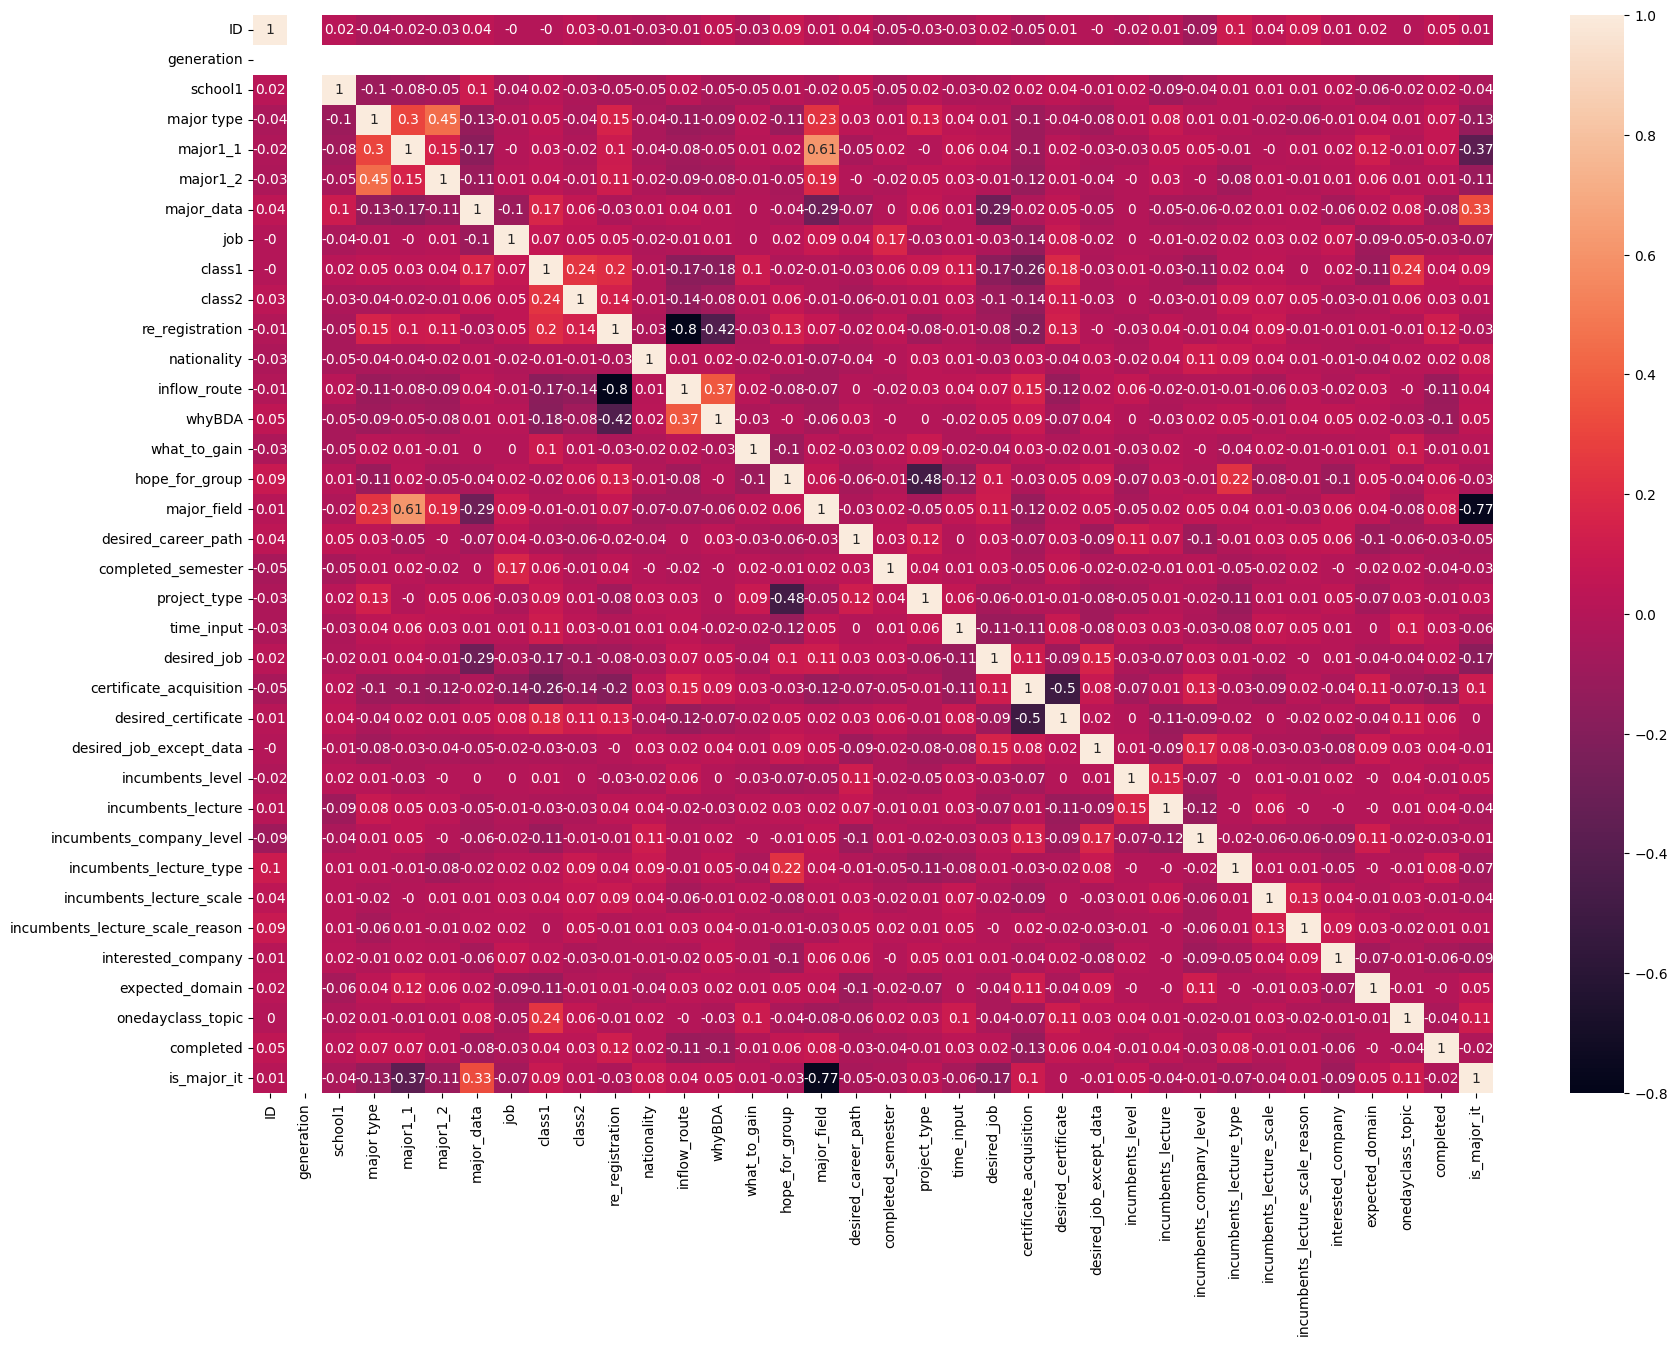

In [66]:
plt.figure(figsize=(20,14))
sns.heatmap(train.corr().round(2), annot = True)

### 타겟 변수(completed) 분포 확인

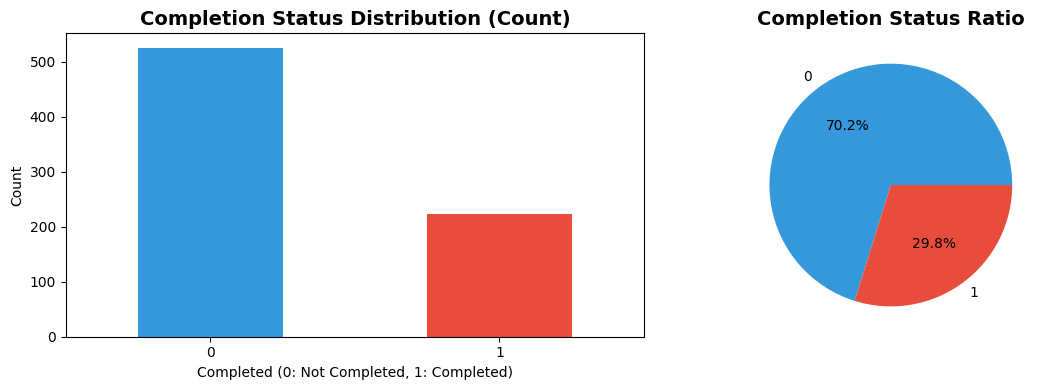

Completed: 223 students (29.81%)
Not Completed: 525 students (70.19%)


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution by count
train['completed'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Completion Status Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Completed (0: Not Completed, 1: Completed)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Distribution by percentage
train['completed'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
axes[1].set_title('Completion Status Ratio', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Completed: {train['completed'].sum()} students ({train['completed'].mean()*100:.2f}%)")
print(f"Not Completed: {(1-train['completed']).sum()} students ({(1-train['completed'].mean())*100:.2f}%)")

### 상관관계 분석 - 타겟과의 상관관계 추출

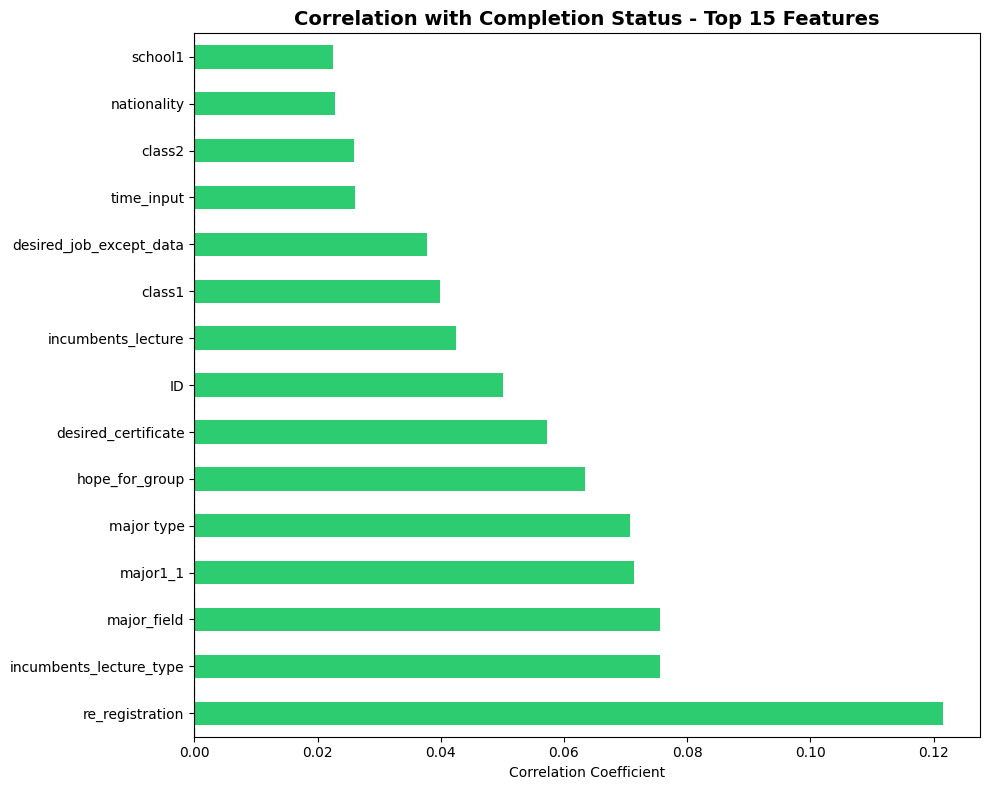

=== Features with High Positive Correlation (Top 10) ===
re_registration            0.121472
incumbents_lecture_type    0.075662
major_field                0.075519
major1_1                   0.071348
major type                 0.070713
hope_for_group             0.063364
desired_certificate        0.057206
ID                         0.050167
incumbents_lecture         0.042522
class1                     0.039896
Name: completed, dtype: float64

=== Features with High Negative Correlation (Bottom 10) ===
incumbents_company_level   -0.028417
desired_career_path        -0.030227
completed_semester         -0.035210
onedayclass_topic          -0.036222
interested_company         -0.062240
major_data                 -0.079470
whyBDA                     -0.098172
inflow_route               -0.105932
certificate_acquisition    -0.125261
generation                       NaN
Name: completed, dtype: float64


In [68]:
# Calculate correlation with target variable
correlation_with_target = train.corr()['completed'].sort_values(ascending=False)

# Visualize top 15 features by correlation
plt.figure(figsize=(10, 8))
top_corr = correlation_with_target[1:16]  # Top 15 excluding completed itself
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_corr.values]
top_corr.plot(kind='barh', color=colors)
plt.title('Correlation with Completion Status - Top 15 Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# Print correlation values
print("=== Features with High Positive Correlation (Top 10) ===")
print(correlation_with_target[1:11])
print("\n=== Features with High Negative Correlation (Bottom 10) ===")
print(correlation_with_target[-10:])

### 주요 특성별 수료 여부 분석

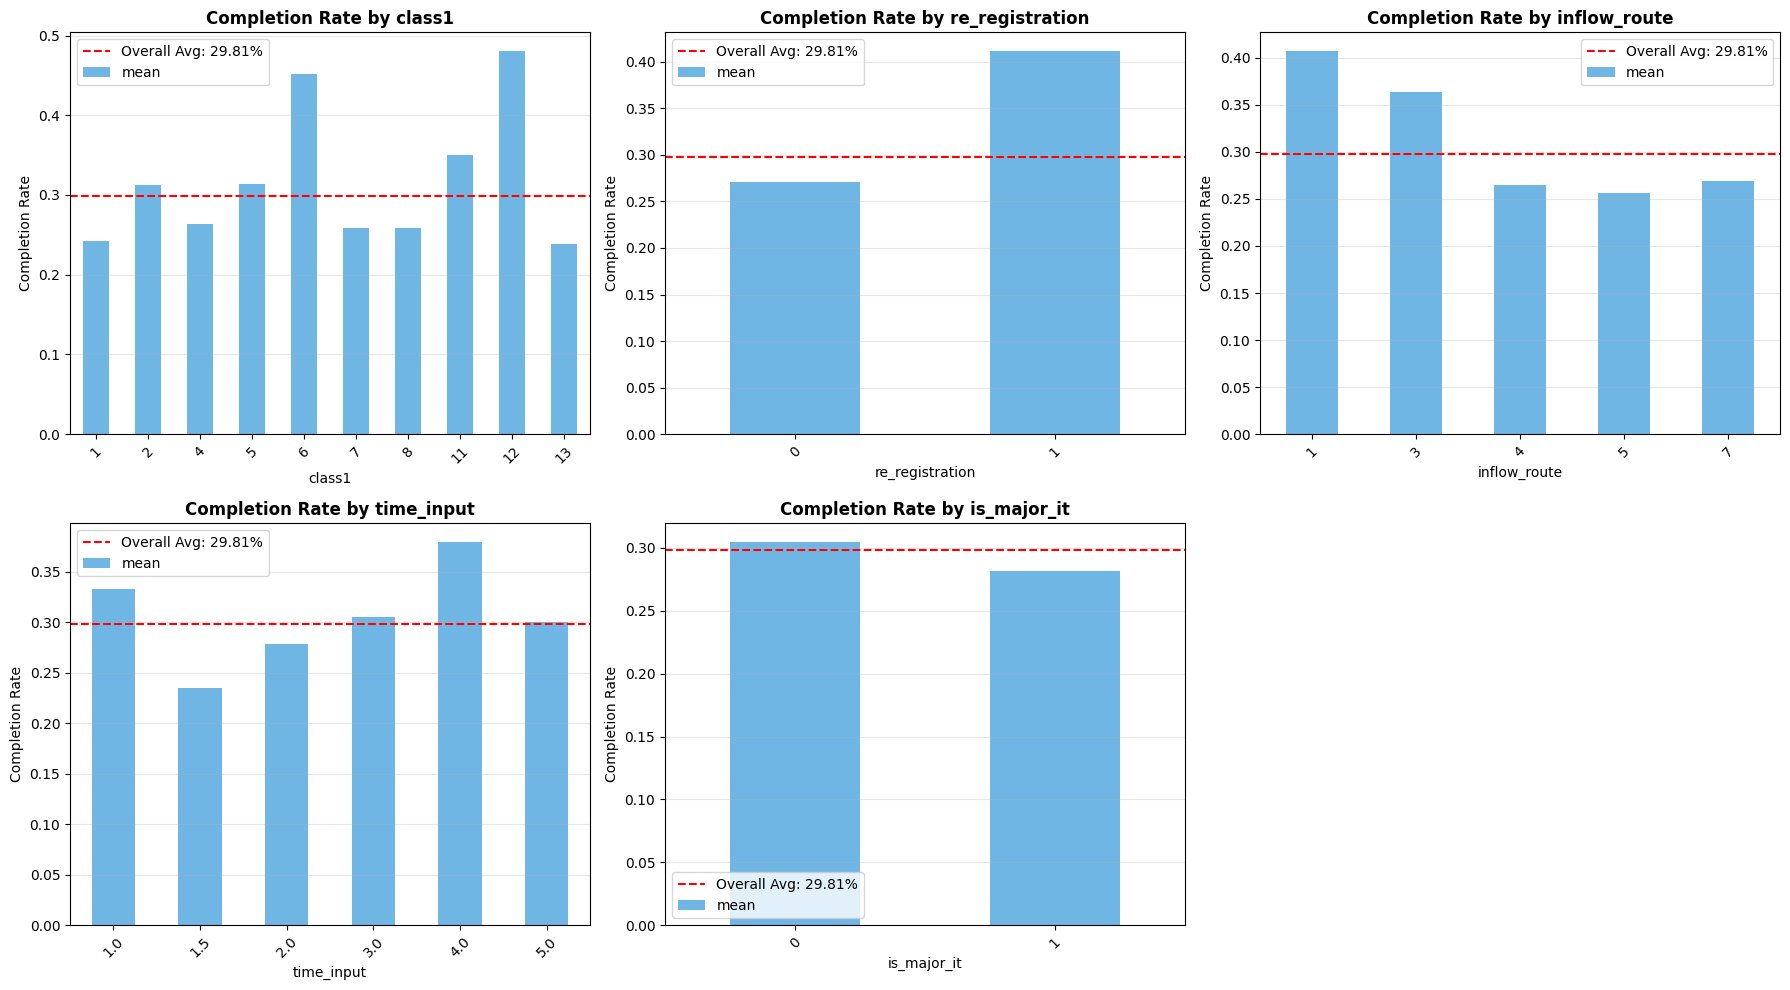

In [69]:
# Completion rate comparison for 5 key features
key_features = ['class1', 're_registration', 'inflow_route', 'time_input', 'is_major_it']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    # Calculate completion rate by feature value
    completion_rate = train.groupby(feature)['completed'].agg(['mean', 'count'])
    completion_rate = completion_rate[completion_rate['count'] > 10]  # Only groups with 10+ samples
    
    # Bar plot
    completion_rate['mean'].plot(kind='bar', ax=axes[idx], color='#3498db', alpha=0.7)
    axes[idx].set_title(f'Completion Rate by {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Completion Rate')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].axhline(y=train['completed'].mean(), color='red', linestyle='--', 
                      label=f'Overall Avg: {train["completed"].mean():.2%}')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 특성 간 Pairplot (주요 특성)

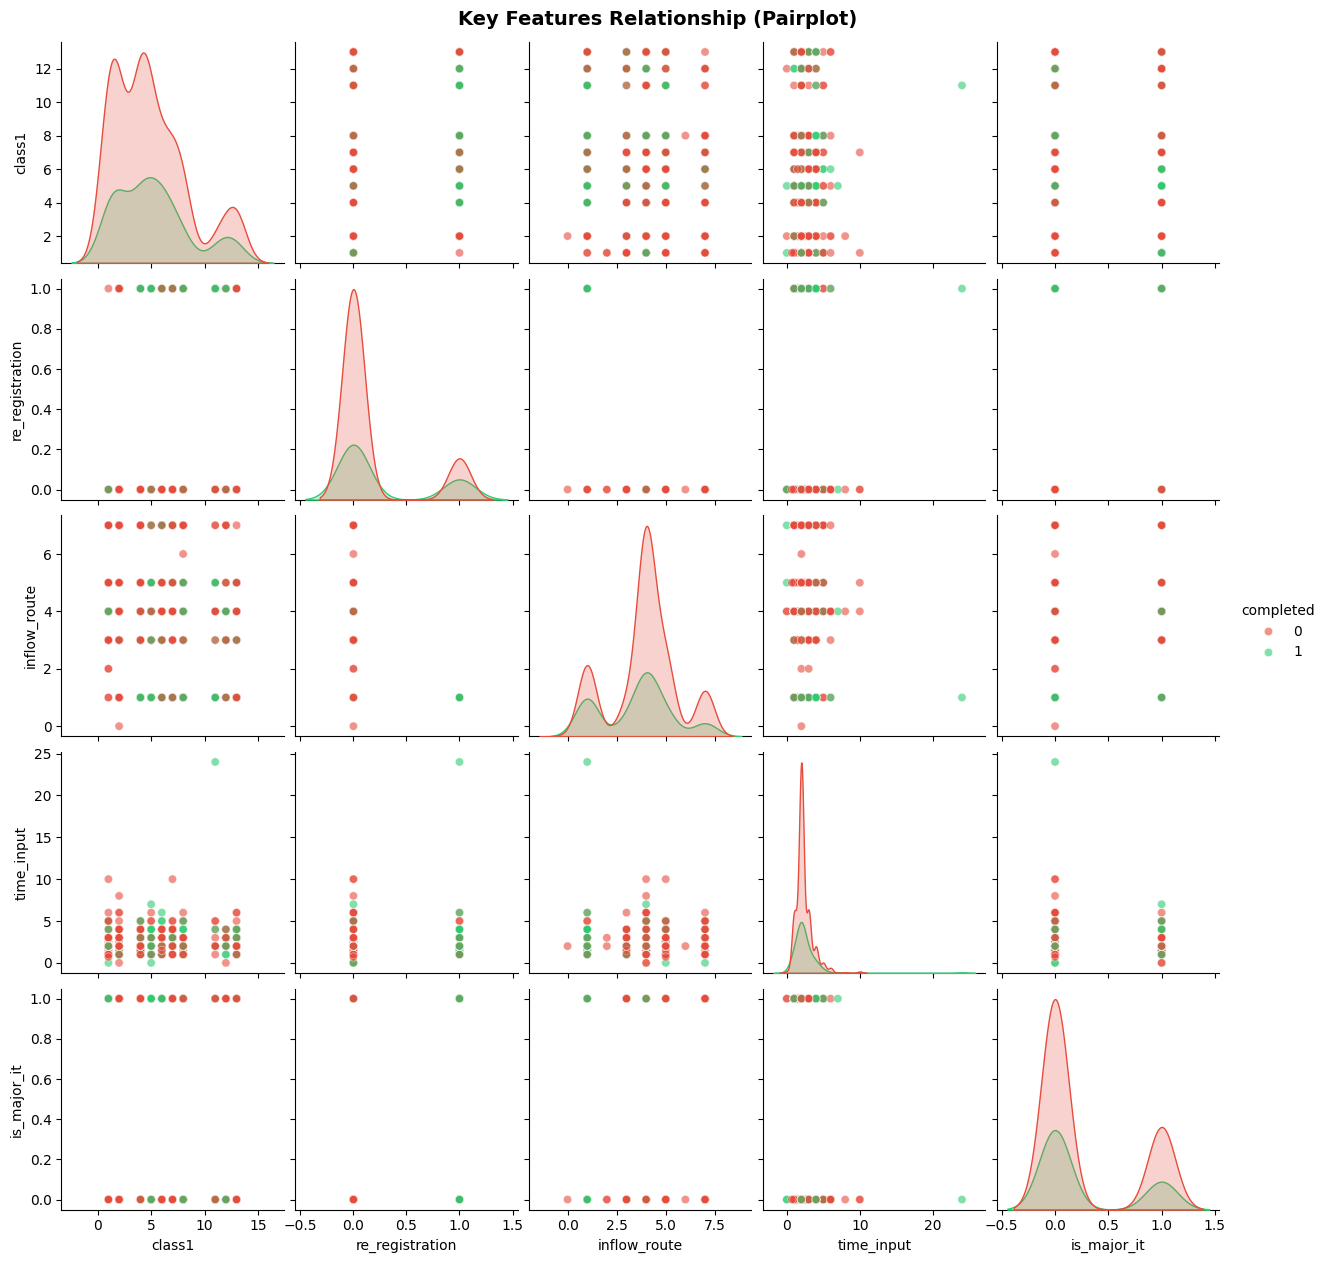

In [70]:
# Visualize relationships between key features using pairplot (with sampling for performance)
sample_size = min(1000, len(train))
train_sample = train.sample(n=sample_size, random_state=42)

selected_features = ['class1', 're_registration', 'inflow_route', 'time_input', 'is_major_it', 'completed']
pairplot_data = train_sample[selected_features]

sns.pairplot(pairplot_data, hue='completed', palette={0: '#e74c3c', 1: '#2ecc71'}, 
             diag_kind='kde', plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Key Features Relationship (Pairplot)', y=1.01, fontsize=14, fontweight='bold')
plt.show()

## Feature Selection & Engineering

### Feature Selection based on Correlation Analysis

In [71]:
# Select features based on correlation with target variable
correlation_with_target = train.corr()['completed'].abs().sort_values(ascending=False)

# Select top features (correlation > 0.05 as threshold, excluding 'completed' itself)
threshold = 0.05
selected_features_by_corr = correlation_with_target[
    (correlation_with_target > threshold) & 
    (correlation_with_target.index != 'completed')
].index.tolist()

print(f"Number of features with |correlation| > {threshold}: {len(selected_features_by_corr)}")
print(f"\nSelected features:")
for feature in selected_features_by_corr[:15]:  # Show top 15
    corr_value = train.corr()['completed'][feature]
    print(f"  {feature:30s}: {corr_value:>7.4f}")
    
if len(selected_features_by_corr) > 15:
    print(f"  ... and {len(selected_features_by_corr) - 15} more features")

Number of features with |correlation| > 0.05: 13

Selected features:
  certificate_acquisition       : -0.1253
  re_registration               :  0.1215
  inflow_route                  : -0.1059
  whyBDA                        : -0.0982
  major_data                    : -0.0795
  incumbents_lecture_type       :  0.0757
  major_field                   :  0.0755
  major1_1                      :  0.0713
  major type                    :  0.0707
  hope_for_group                :  0.0634
  interested_company            : -0.0622
  desired_certificate           :  0.0572
  ID                            :  0.0502


### Prepare Features and Target

In [72]:
# Option 1: Use manually selected features (baseline approach)
manual_features = ['class1', 're_registration', 'inflow_route', 'time_input', 'is_major_it']

# Option 2: Use correlation-based selected features
# Uncomment below to use correlation-based features
# selected_features = selected_features_by_corr

# For now, use manual features
selected_features = manual_features

X_train = train[selected_features]
y_train = train['completed']

X_test = test[selected_features]

print(f"Number of features selected: {len(selected_features)}")
print(f"Features: {selected_features}")
print(f"\nTraining data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Number of features selected: 5
Features: ['class1', 're_registration', 'inflow_route', 'time_input', 'is_major_it']

Training data shape: (748, 5)
Test data shape: (814, 5)


### Data Normalization / Standardization

=== Data Statistics Before Scaling ===
           class1  re_registration  inflow_route  time_input  is_major_it
count  748.000000       748.000000    748.000000  748.000000   748.000000
mean     4.970588         0.195187      3.791444    2.326471     0.275401
std      3.412975         0.396610      1.725261    1.365925     0.447015
min      1.000000         0.000000      0.000000    0.000000     0.000000
25%      2.000000         0.000000      3.000000    2.000000     0.000000
50%      4.000000         0.000000      4.000000    2.000000     0.000000
75%      7.000000         0.000000      5.000000    3.000000     1.000000
max     13.000000         1.000000      7.000000   24.000000     1.000000


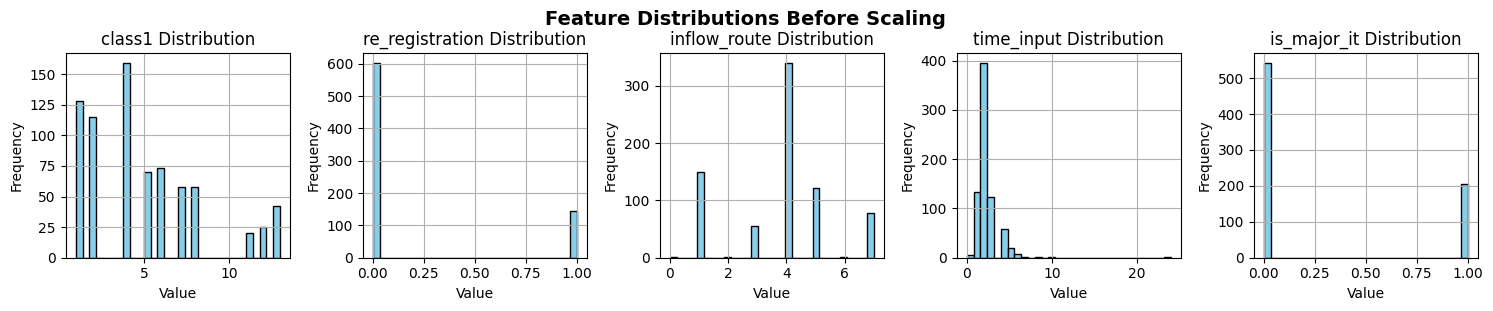

In [73]:
# Check data distribution before scaling
print("=== Data Statistics Before Scaling ===")
print(X_train.describe())

# Visualize feature distributions before scaling
fig, axes = plt.subplots(1, min(5, len(selected_features)), figsize=(15, 3))
if len(selected_features) == 1:
    axes = [axes]
    
for idx, feature in enumerate(selected_features[:5]):
    X_train[feature].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Feature Distributions Before Scaling', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [74]:
# Apply StandardScaler (mean=0, std=1)
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features, index=X_test.index)

print("=== Data Statistics After Scaling ===")
print(X_train_scaled.describe())
print("\n✓ Features are now standardized (mean ≈ 0, std ≈ 1)")

=== Data Statistics After Scaling ===
             class1  re_registration  inflow_route    time_input   is_major_it
count  7.480000e+02     7.480000e+02  7.480000e+02  7.480000e+02  7.480000e+02
mean  -2.137328e-17    -1.187404e-17 -5.224579e-17 -1.543626e-16  2.374809e-17
std    1.000669e+00     1.000669e+00  1.000669e+00  1.000669e+00  1.000669e+00
min   -1.164159e+00    -4.924682e-01 -2.199076e+00 -1.704360e+00 -6.165013e-01
25%   -8.709633e-01    -4.924682e-01 -4.590455e-01 -2.391706e-01 -6.165013e-01
50%   -2.845722e-01    -4.924682e-01  1.209647e-01 -2.391706e-01 -6.165013e-01
75%    5.950145e-01    -4.924682e-01  7.009749e-01  4.934240e-01  1.622057e+00
max    2.354188e+00     2.030588e+00  1.860995e+00  1.587791e+01  1.622057e+00

✓ Features are now standardized (mean ≈ 0, std ≈ 1)


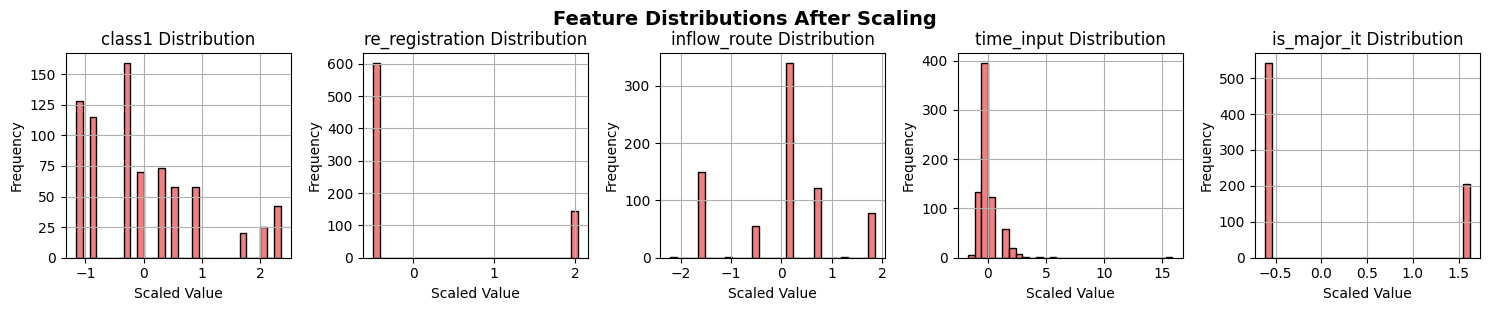

In [75]:
# Visualize feature distributions after scaling
fig, axes = plt.subplots(1, min(5, len(selected_features)), figsize=(15, 3))
if len(selected_features) == 1:
    axes = [axes]
    
for idx, feature in enumerate(selected_features[:5]):
    X_train_scaled[feature].hist(bins=30, ax=axes[idx], color='lightcoral', edgecolor='black')
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].set_xlabel('Scaled Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Feature Distributions After Scaling', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Comparison: Original vs Scaled Data (Optional)

In [76]:
# Compare model performance with original vs scaled data
# Train model with original (unscaled) data
X_tr_orig, X_val_orig, y_tr_orig, y_val_orig = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

model_original = RandomForestClassifier(random_state=42, n_estimators=100)
model_original.fit(X_tr_orig, y_tr_orig)
y_pred_original = model_original.predict(X_val_orig)

# Train model with scaled data
model_scaled = RandomForestClassifier(random_state=42, n_estimators=100)
X_tr_scaled, X_val_scaled, y_tr_scaled, y_val_scaled = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train)
model_scaled.fit(X_tr_scaled, y_tr_scaled)
y_pred_scaled = model_scaled.predict(X_val_scaled)

# Compare performance
acc_original = accuracy_score(y_val_orig, y_pred_original)
f1_original = f1_score(y_val_orig, y_pred_original)

acc_scaled = accuracy_score(y_val_scaled, y_pred_scaled)
f1_scaled = f1_score(y_val_scaled, y_pred_scaled)

print("="*60)
print("Performance Comparison: Original vs Scaled Data")
print("="*60)
print(f"{'Metric':<20} {'Original Data':>15} {'Scaled Data':>15} {'Difference':>12}")
print("-"*60)
print(f"{'Accuracy':<20} {acc_original:>14.4f} {acc_scaled:>15.4f} {acc_scaled-acc_original:>12.4f}")
print(f"{'F1-Score':<20} {f1_original:>14.4f} {f1_scaled:>15.4f} {f1_scaled-f1_original:>12.4f}")
print("="*60)
print("\nNote: For RandomForest, scaling typically has minimal impact.")
print("However, for algorithms like Logistic Regression, SVM, or Neural Networks,")
print("scaling is crucial for optimal performance.")

Performance Comparison: Original vs Scaled Data
Metric                 Original Data     Scaled Data   Difference
------------------------------------------------------------
Accuracy                     0.6533          0.6533       0.0000
F1-Score                     0.2973          0.2973       0.0000

Note: For RandomForest, scaling typically has minimal impact.
However, for algorithms like Logistic Regression, SVM, or Neural Networks,
scaling is crucial for optimal performance.


## Modeling (with Scaled Data)

In [77]:
# Train RandomForest with scaled data
# Note: RandomForest is not sensitive to feature scaling, but we do it for consistency
# and to enable comparison with other algorithms (like Logistic Regression, SVM, etc.)

model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train_scaled, y_train)

print("✓ Model training completed")
print(f"Model: {model.__class__.__name__}")
print(f"Number of trees: {model.n_estimators}")
print(f"Training samples: {len(X_train_scaled)}")

✓ Model training completed
Model: RandomForestClassifier
Number of trees: 100
Training samples: 748


## Model Evaluation (혼동행렬 및 성능 분석)

In [78]:
# Split data for validation (using scaled data)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Train model
val_model = RandomForestClassifier(random_state=42, n_estimators=100)
val_model.fit(X_tr, y_tr)

# Predict on validation data
y_pred = val_model.predict(X_val)

print(f"Validation data size: {len(X_val)} samples")
print(f"Training data size: {len(X_tr)} samples")

Validation data size: 150 samples
Training data size: 598 samples


### 혼동행렬 (Confusion Matrix) 시각화 및 분석

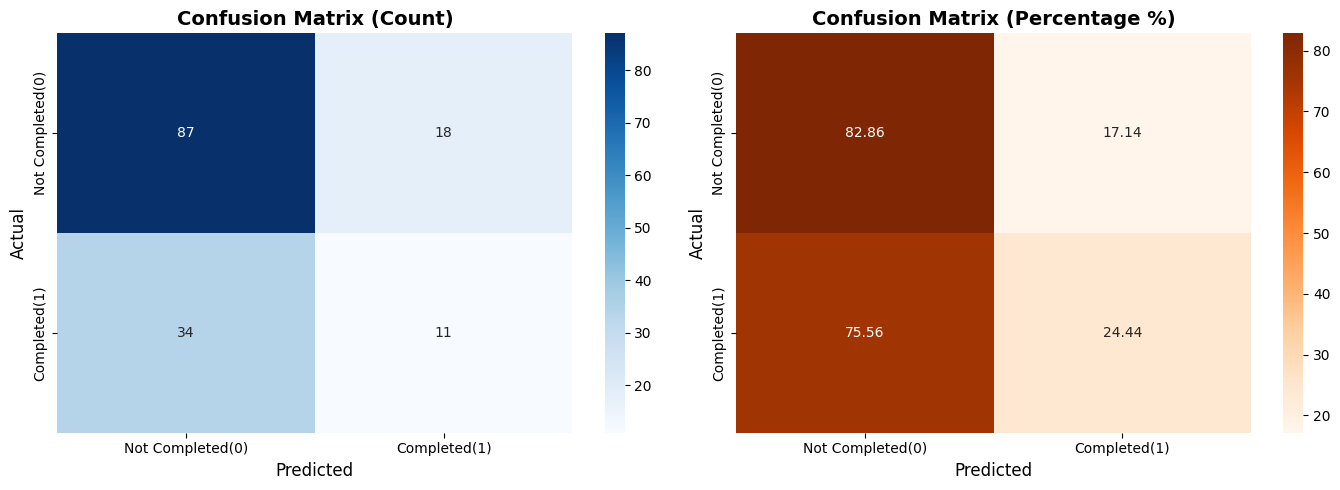

Confusion Matrix Analysis
True Negative (TN):     87 - Correctly predicted as Not Completed
False Positive (FP):    18 - Incorrectly predicted as Completed (Type I Error)
False Negative (FN):    34 - Incorrectly predicted as Not Completed (Type II Error)
True Positive (TP):     11 - Correctly predicted as Completed


In [79]:
# Calculate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Count-based confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['Not Completed(0)', 'Completed(1)'], yticklabels=['Not Completed(0)', 'Completed(1)'])
axes[0].set_title('Confusion Matrix (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# 2. Percentage-based confusion matrix
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Oranges', cbar=True, ax=axes[1],
            xticklabels=['Not Completed(0)', 'Completed(1)'], yticklabels=['Not Completed(0)', 'Completed(1)'])
axes[1].set_title('Confusion Matrix (Percentage %)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

# Extract confusion matrix elements
tn, fp, fn, tp = cm.ravel()

print("="*60)
print("Confusion Matrix Analysis")
print("="*60)
print(f"True Negative (TN):  {tn:5d} - Correctly predicted as Not Completed")
print(f"False Positive (FP): {fp:5d} - Incorrectly predicted as Completed (Type I Error)")
print(f"False Negative (FN): {fn:5d} - Incorrectly predicted as Not Completed (Type II Error)")
print(f"True Positive (TP):  {tp:5d} - Correctly predicted as Completed")
print("="*60)

### 성능 지표 (Performance Metrics)

In [80]:
# Calculate performance metrics
accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

# Calculate Precision, Recall
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("="*60)
print("Model Performance Metrics")
print("="*60)
print(f"Accuracy:              {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  → Ratio of correct predictions among all predictions")
print()
print(f"Precision:             {precision:.4f} ({precision*100:.2f}%)")
print(f"  → Ratio of actual completed among predicted completed")
print(f"  → TP / (TP + FP) = {tp} / ({tp} + {fp})")
print()
print(f"Recall (Sensitivity):  {recall:.4f} ({recall*100:.2f}%)")
print(f"  → Ratio of predicted completed among actual completed")
print(f"  → TP / (TP + FN) = {tp} / ({tp} + {fn})")
print()
print(f"Specificity:           {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  → Ratio of predicted not completed among actual not completed")
print(f"  → TN / (TN + FP) = {tn} / ({tn} + {fp})")
print()
print(f"F1-Score:              {f1:.4f}")
print(f"  → Harmonic mean of Precision and Recall")
print("="*60)

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Completed(0)', 'Completed(1)']))

Model Performance Metrics
Accuracy:              0.6533 (65.33%)
  → Ratio of correct predictions among all predictions

Precision:             0.3793 (37.93%)
  → Ratio of actual completed among predicted completed
  → TP / (TP + FP) = 11 / (11 + 18)

Recall (Sensitivity):  0.2444 (24.44%)
  → Ratio of predicted completed among actual completed
  → TP / (TP + FN) = 11 / (11 + 34)

Specificity:           0.8286 (82.86%)
  → Ratio of predicted not completed among actual not completed
  → TN / (TN + FP) = 87 / (87 + 18)

F1-Score:              0.2973
  → Harmonic mean of Precision and Recall

Classification Report:
                  precision    recall  f1-score   support

Not Completed(0)       0.72      0.83      0.77       105
    Completed(1)       0.38      0.24      0.30        45

        accuracy                           0.65       150
       macro avg       0.55      0.54      0.53       150
    weighted avg       0.62      0.65      0.63       150



### 특성 중요도 (Feature Importance)

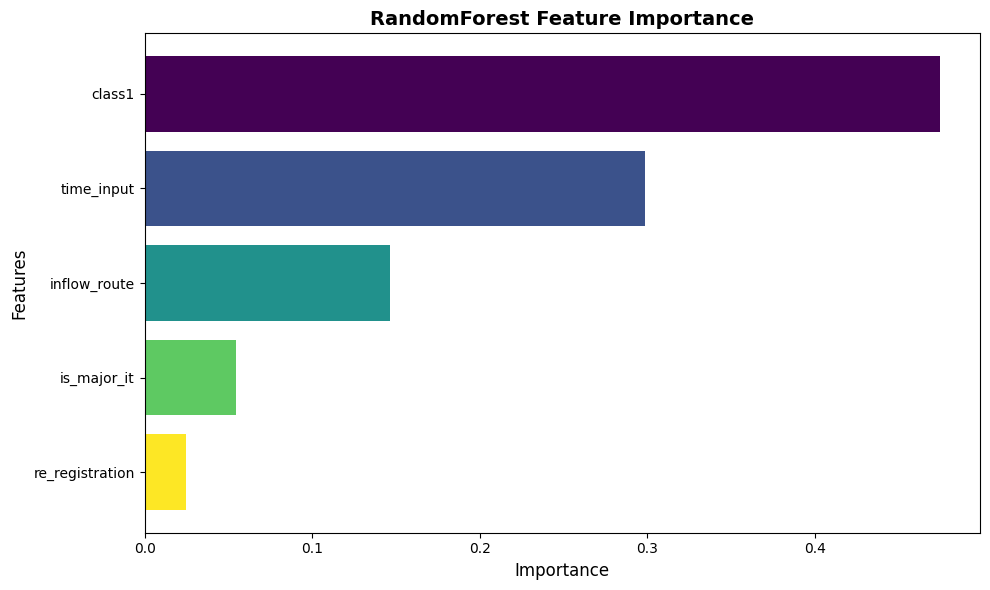

Feature Importance:
  class1              : 0.4749 (47.49%)
  time_input          : 0.2989 (29.89%)
  inflow_route        : 0.1467 (14.67%)
  is_major_it         : 0.0548 (5.48%)
  re_registration     : 0.0247 (2.47%)


In [81]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': val_model.feature_importances_
}).sort_values('importance', ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('RandomForest Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature Importance:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

### Model Performance Summary

**Confusion Matrix Interpretation Guide:**
- **True Positive (TP)**: Correctly predicted completed students ✓
- **True Negative (TN)**: Correctly predicted not completed students ✓
- **False Positive (FP)**: Incorrectly predicted as completed ✗ (Type I Error)
- **False Negative (FN)**: Incorrectly predicted as not completed ✗ (Type II Error)

**Performance Metrics Meaning:**
- **Accuracy**: Overall prediction accuracy
- **Precision**: Reliability of completion prediction (ratio of actual completed among predicted completed)
- **Recall**: Actual completer capture rate (ratio of predicted completed among actual completed)
- **F1-Score**: Balanced metric between Precision and Recall

**Improvement Directions:**
1. If FP is high → Need to improve Precision to avoid missing non-completers
2. If FN is high → Need to improve Recall to avoid missing completers
3. Consider adding more important features based on feature importance analysis

## Inference

In [82]:
# Make predictions on test data (using scaled features)
pred = model.predict(X_test_scaled)

print(f"Predictions generated: {len(pred)}")
print(f"Predicted completion count: {pred.sum()}")
print(f"Predicted completion rate: {pred.mean()*100:.2f}%")

Predictions generated: 814
Predicted completion count: 133
Predicted completion rate: 16.34%


## Submission

In [83]:
submission = pd.read_csv('open/sample_submission.csv')
submission['completed'] = pred
submission.to_csv('submit.csv', index = False)